# Interactive plot for the functions:

$\Large f_{p,q}(x) = \frac{p \cdot x + q}{\sqrt{x^2 + 1}}$

$\Large g_{q}(x) = x^2 - q$

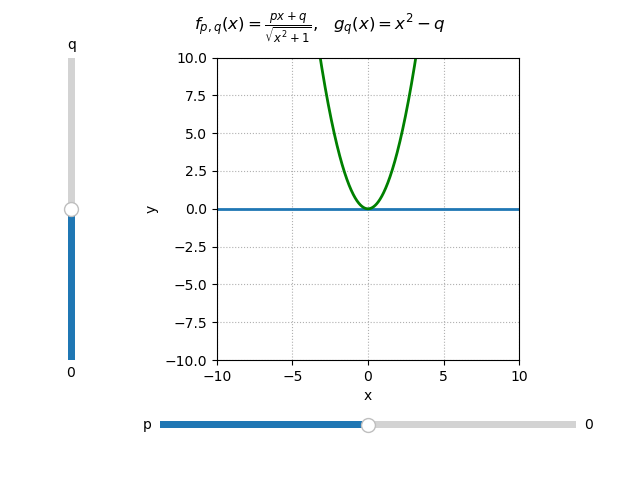

In [1]:
# IPython magic command for enabling interactive matplotlib plots in Jupyter
# notebook (disable when executing this code with a regular Python
# interpreter).
%matplotlib widget

# Imports
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt
import numpy as np

# Parameters `x`, `p` and `q` have a static range
x_min = -10.0
x_max = 10.0
x = np.linspace(x_min, x_max, 1000)

p_init = 0.0
p_min = -5.0
p_max = 5.0
p = np.linspace(p_min, p_max, 1000)

q_init = 0.0
q_min = -5.0
q_max = 5.0
q = np.linspace(q_min, q_max, 1000)

# Value `y` for function `f` is calculated from `x`, `p` en `q`
def func_f(x, p, q):
    return (p * x + q) / np.sqrt(x ** 2 + 1)

# Value `y` for parabola function `g` is calculated `x` and `q`
def func_g(x, q):
    return x ** 2 - q

# Latex string representation of functions
func_str = "$f_{p,q}(x)=\\frac{px+q}{\\sqrt{x^2+1}}$,   $g_q(x)=x^2-q$"

# Set axes limits
xlim = (x_min, x_max)
ylim = (x_min, x_max)

# Initialize figure with axes
fig = plt.figure()
axes = plt.axes(
    xlim=xlim,
    ylim=ylim,
)
axes.set_aspect("equal")
axes.grid(linestyle="dotted")
axes.set_xlabel("x")
axes.set_ylabel("y")

# Print equation of plotted function above axes
fig.suptitle(func_str)

# Expand figure window to make room for sliders
fig.subplots_adjust(left=0.25, bottom=0.25)

# Make a horizontal slider for `p`
axes_slider_p = fig.add_axes([0.25, 0.1, 0.65, 0.03])
slider_p = Slider(
    ax=axes_slider_p,
    label="p",
    valmin=p_min,
    valmax=p_max,
    valinit=p_init,
)

# Make a vertically oriented slider for `q`
axes_slider_q = fig.add_axes([0.1, 0.25, 0.0225, 0.63])
slider_q = Slider(
    ax=axes_slider_q,
    label="q",
    valmin=q_min,
    valmax=q_max,
    valinit=q_init,
    orientation="vertical"
)

# Initialize lines
yf_init = func_f(x, p_init, q_init)
line_f, = axes.plot(x, yf_init, lw = 2)
yg_init = func_g(x, q_init)
line_g, = axes.plot(x, yg_init, lw = 2, color="g")

# Function for updating plot when a slider changes value
def update(_):
    p = slider_p.val
    q = slider_q.val
    yf = func_f(x, p, q)
    yg = func_g(x, q)
    line_f.set_ydata(yf)
    line_g.set_ydata(yg)
    fig.canvas.draw_idle()

# Link sliders to plot update function
slider_p.on_changed(update)
slider_q.on_changed(update)

# Show plot
plt.show()
